In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv("Mall_Customers.csv")
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
X = dataset.iloc[: , [3,4]].values

In [4]:
#from sklearn.metrics import silhouette_score
# preferences = np.linspace(-50, -10, 5)
# sil_scores = []
# from sklearn.cluster import AffinityPropagation
# for pref in preferences:
#     clustering = AffinityPropagation(damping=0.5, preference=pref, random_state=42)
#     clustering.fit(X)
#     if len(set(clustering.labels_))>1:
#         sil_score = silhouette_score(X, clustering.labels_)
#         sil_scores.append((pref, sil_score))
# prefs, scores = zip(*sil_scores)
# plt.figure(figsize=(8, 5))
# plt.plot(prefs, scores, marker='o')
# plt.title('Preference vs Silhouette Score')
# plt.xlabel('Preference')
# plt.ylabel('Silhouette Score')
# plt.show()

In [5]:
from sklearn.cluster import AffinityPropagation
clustering = AffinityPropagation(damping=0.5, random_state=42)
y = clustering.fit_predict(X)
y

array([ 2,  1,  0,  1,  2,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  2,
        1,  2,  1,  2,  1,  0,  1,  0,  1,  2,  3,  2,  1,  0,  1,  0,  1,
        0,  1,  0,  1,  2,  1,  2,  1,  2,  3,  2,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  5,  4,  5,  5,  4,  4,  4,  5,  4,  5,  4,
        4,  4,  4,  5,  4,  4,  5,  4,  4,  4,  5,  5,  4,  4,  5,  4,  5,
        4,  4,  5,  4,  7,  5,  8,  5,  7,  6,  8,  6,  8,  5,  8,  6,  7,
        6,  8,  6,  8,  6,  7,  5,  7,  6,  7,  5,  8,  6,  7,  6,  7,  6,
        8,  6,  7,  6,  8,  6,  8,  5,  7,  6,  7,  6,  8,  6,  7, 10,  8,
        6,  8,  6,  7,  6,  7,  6,  8, 10,  9, 10,  9, 10,  9, 10,  9, 10,
        9, 10,  9, 10,  9, 10,  9, 10,  9, 10,  9, 10,  9], dtype=int64)

In [6]:
supervised = dataset
supervised["Cluster_grup"] = y
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_grup
0,1,Male,19,15,39,2
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,2
...,...,...,...,...,...,...
195,196,Female,35,120,79,9
196,197,Female,45,126,28,10
197,198,Male,32,126,74,9
198,199,Male,32,137,18,10


In [7]:
#if you wanna see silloute score
from sklearn.metrics import silhouette_score
score = silhouette_score(X, y)
print("Silhouette Score: ", score)

Silhouette Score:  0.4317941560811469


In [8]:
supervised.to_csv("cluster_Aff.csv", index=False)

C:\Anaconda3\envs\aiml\lib\site-packages\seaborn\regression.py:582: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


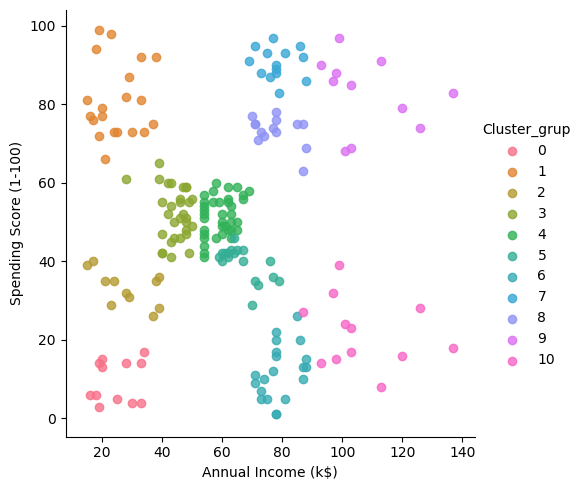

In [9]:
import seaborn as sns
facet = sns.lmplot(data=supervised, x=supervised.columns[3] , y=supervised.columns[4], hue = supervised.columns[5], fit_reg = False, legend=True, legend_out = True)

In [10]:
#if you want to see number of clusters
n_clusters_ = len(np.unique(y))
n_clusters_

11